In [ ]:
!pip install torch torchvision torchaudio --index-url https://download.pytorch.org/whl/cu121
!pip install diffusers transformers accelerate datasets einops matplotlib pillow tqdm
!pip install data
!pip install gdown

In [1]:
import os
import math
import random
from PIL import Image

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms
from torchvision.utils import save_image, make_grid

import matplotlib.pyplot as plt
from tqdm import tqdm

In [2]:
if torch.backends.mps.is_available():
    device = torch.device("mps")
elif torch.cuda.is_available():
    device = torch.device("cuda")
else:
    device = torch.device("cpu")

print("Using device:", device)

Using device: mps


In [102]:
class ImageFolderDataset(Dataset):
    def __init__(self, image_dir, image_size=64, augment=False):
        self.image_paths = sorted([
            os.path.join(image_dir, f)
            for f in os.listdir(image_dir)
            if f.lower().endswith((".jpg", ".jpeg", ".png"))
        ])

        if augment:
            self.transform = transforms.Compose([
                transforms.Resize((image_size + 8, image_size + 8)),
                transforms.RandomCrop((image_size, image_size)),
                transforms.RandomHorizontalFlip(),
                transforms.ColorJitter(brightness=0.1, contrast=0.1, saturation=0.1),
                transforms.ToTensor(),
                transforms.Normalize([0.5, 0.5, 0.5],
                                     [0.5, 0.5, 0.5]),
            ])
        else:
            self.transform = transforms.Compose([
                transforms.Resize((image_size, image_size)),
                transforms.ToTensor(),
                transforms.Normalize([0.5, 0.5, 0.5],
                                     [0.5, 0.5, 0.5]),
            ])

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img = Image.open(self.image_paths[idx]).convert("RGBA")
        bg = Image.new("RGBA", img.size, (255, 255, 255, 255))
        img = Image.alpha_composite(bg, img).convert("RGB")
        img = self.transform(img)
        return img, 0

In [103]:
def get_train_test_dataloaders(
    image_dir="./data/pokemon_images",
    image_size=64,
    batch_size=16,
    num_workers=0,
    train_ratio=0.8,
    seed=42,
):
    full_dataset = ImageFolderDataset(
        image_dir=image_dir,
        image_size=image_size,
        augment=False,
    )

    train_size = int(train_ratio * len(full_dataset))
    test_size = len(full_dataset) - train_size

    generator = torch.Generator().manual_seed(seed)
    train_indices, test_indices = random_split(
        range(len(full_dataset)),
        [train_size, test_size],
        generator=generator
    )

    train_dataset = torch.utils.data.Subset(
        ImageFolderDataset(image_dir=image_dir, image_size=image_size, augment=True),
        train_indices.indices
    )

    test_dataset = torch.utils.data.Subset(
        ImageFolderDataset(image_dir=image_dir, image_size=image_size, augment=False),
        test_indices.indices
    )

    train_loader = DataLoader(
        train_dataset,
        batch_size=batch_size,
        shuffle=True,
        num_workers=num_workers,
        drop_last=True,
        pin_memory=False,
    )

    test_loader = DataLoader(
        test_dataset,
        batch_size=batch_size,
        shuffle=False,
        num_workers=num_workers,
        drop_last=False,
        pin_memory=False,
    )

    return train_loader, test_loader

In [104]:
train_loader, test_loader = get_train_test_dataloaders(
    image_dir="./data/pokemon_images",
    image_size=64,
    batch_size=16,
    num_workers=0,
    train_ratio=0.8,
)

print("Train batches:", len(train_loader))
print("Test batches:", len(test_loader))

sample_imgs, _ = next(iter(train_loader))
print("Sample batch shape:", sample_imgs.shape)

Train batches: 40
Test batches: 11
Sample batch shape: torch.Size([16, 3, 64, 64])


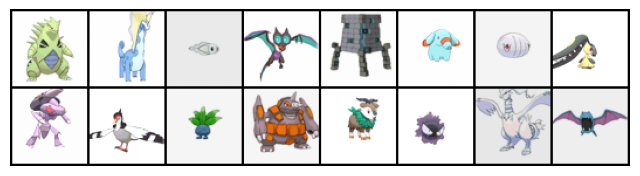

In [105]:
real_batch, _ = next(iter(train_loader))
show_tensor_grid(real_batch, nrow=8, figsize=(8, 8))

In [106]:
def denorm(x):
    return (x + 1.0) / 2.0

def save_samples(images, path, nrow=8):
    folder = os.path.dirname(path)
    if folder:
        os.makedirs(folder, exist_ok=True)
    grid = make_grid(denorm(images[:nrow * nrow].detach().cpu()), nrow=nrow)
    save_image(grid, path)

def show_tensor_grid(images, nrow=8, figsize=(8, 8)):
    grid = make_grid(denorm(images[:nrow * nrow].detach().cpu()), nrow=nrow)
    plt.figure(figsize=figsize)
    plt.imshow(grid.permute(1, 2, 0))
    plt.axis("off")
    plt.show()

In [107]:
import os
import torch
from torchvision.utils import save_image, make_grid

def denorm(x):
    return (x + 1) / 2

def save_samples(images, path, nrow=8):
    os.makedirs(os.path.dirname(path), exist_ok=True)
    grid = make_grid(denorm(images[:nrow*nrow].detach().cpu()), nrow=nrow)
    save_image(grid, path)

def gradient_penalty(critic, real, fake, device):
    bsz = real.size(0)
    eps = torch.rand(bsz, 1, 1, 1, device=device)
    interp = eps * real + (1 - eps) * fake
    interp.requires_grad_(True)

    score = critic(interp)
    grads = torch.autograd.grad(
        outputs=score,
        inputs=interp,
        grad_outputs=torch.ones_like(score),
        create_graph=True,
        retain_graph=True,
    )[0]

    grads = grads.view(bsz, -1)
    return ((grads.norm(2, dim=1) - 1) ** 2).mean()

In [108]:
class Discriminator(nn.Module):
    def __init__(self, ndf=64, nc=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)

def weights_init(m):
    classname = m.__class__.__name__
    if "Conv" in classname:
        nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        nn.init.normal_(m.weight.data, 1.0, 0.02)
        nn.init.constant_(m.bias.data, 0)

In [109]:
LATENT_DIM = 64

class DCGANGenerator(nn.Module):
    def __init__(self, z_dim=128, ngf=64, nc=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, ngf * 8, 4, 1, 0, bias=False),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1, bias=False),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)


class DCGANDiscriminator(nn.Module):
    def __init__(self, ndf=64, nc=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1, bias=False),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 2),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 4),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1, bias=False),
            nn.BatchNorm2d(ndf * 8),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 8, 1, 4, 1, 0, bias=False),
            nn.Sigmoid(),
        )

    def forward(self, x):
        return self.net(x).view(-1, 1)


def weights_init(m):
    classname = m.__class__.__name__
    if "Conv" in classname:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 0.0, 0.02)
    elif "BatchNorm" in classname:
        if hasattr(m, "weight") and m.weight is not None:
            nn.init.normal_(m.weight.data, 1.0, 0.02)
        if hasattr(m, "bias") and m.bias is not None:
            nn.init.constant_(m.bias.data, 0)

In [110]:
def train_dcgan(
    train_loader,
    epochs=10,
    latent_dim=128,
    lr=2e-4,
    beta1=0.5,
    beta2=0.999,
):
    os.makedirs("samples/dcgan", exist_ok=True)

    G = DCGANGenerator(latent_dim).to(device)
    D = DCGANDiscriminator().to(device)
    G.apply(weights_init)
    D.apply(weights_init)

    criterion = nn.BCELoss()
    optG = optim.Adam(G.parameters(), lr=lr, betas=(beta1, beta2))
    optD = optim.Adam(D.parameters(), lr=lr, betas=(beta1, beta2))

    fixed_z = torch.randn(64, latent_dim, 1, 1, device=device)

    history = {
        "lossD": [],
        "lossG": [],
        "d_real_mean": [],
        "d_fake_mean": [],
    }

    for epoch in range(epochs):
        G.train()
        D.train()

        epoch_lossD = 0.0
        epoch_lossG = 0.0
        epoch_d_real = 0.0
        epoch_d_fake = 0.0
        num_batches = 0

        pbar = tqdm(train_loader, desc=f"DCGAN Epoch {epoch+1}/{epochs}")
        for real, _ in pbar:
            real = real.to(device)
            bsz = real.size(0)

            real_y = torch.ones(bsz, 1, device=device) * 0.9
            fake_y = torch.zeros(bsz, 1, device=device)

            z = torch.randn(bsz, latent_dim, 1, 1, device=device)
            fake = G(z)

            d_real = D(real)
            d_fake_detached = D(fake.detach())
            lossD = criterion(d_real, real_y) + criterion(d_fake_detached, fake_y)

            optD.zero_grad()
            lossD.backward()
            optD.step()

            d_fake = D(fake)
            lossG = criterion(d_fake, real_y)

            optG.zero_grad()
            lossG.backward()
            optG.step()

            epoch_lossD += lossD.item()
            epoch_lossG += lossG.item()
            epoch_d_real += d_real.mean().item()
            epoch_d_fake += d_fake.mean().item()
            num_batches += 1

            pbar.set_postfix(
                lossD=float(lossD.item()),
                lossG=float(lossG.item())
            )

        history["lossD"].append(epoch_lossD / num_batches)
        history["lossG"].append(epoch_lossG / num_batches)
        history["d_real_mean"].append(epoch_d_real / num_batches)
        history["d_fake_mean"].append(epoch_d_fake / num_batches)

        with torch.no_grad():
            samples = G(fixed_z)
            save_samples(samples, f"samples/dcgan/epoch_{epoch+1:03d}.png")

    torch.save(G.state_dict(), "dcgan_generator.pt")
    torch.save(D.state_dict(), "dcgan_discriminator.pt")
    torch.save(history, "dcgan_history.pt")

    return G, D, history

In [111]:
G_dcgan, D_dcgan, hist_dcgan = train_dcgan(
    train_loader=train_loader,
    epochs=200,
    latent_dim=64,
    lr=2e-4,
    beta1=0.5,
    beta2=0.999,
)

DCGAN Epoch 200/200: 100%|██████████| 40/40 [00:02<00:00, 17.11it/s, lossD=1.09, lossG=2.06]  


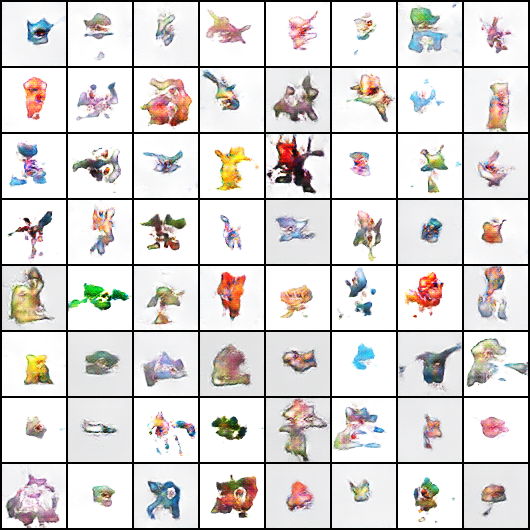

In [139]:
display(Image.open("samples/dcgan/epoch_200.png"))

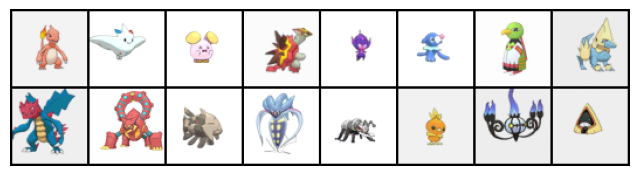

In [93]:
real_batch, _ = next(iter(train_loader))
show_tensor_grid(real_batch)

WGAN

In [113]:
class WGANGenerator(nn.Module):
    def __init__(self, z_dim=128, ngf=64, nc=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(z_dim, ngf * 8, 4, 1, 0),
            nn.BatchNorm2d(ngf * 8),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 8, ngf * 4, 4, 2, 1),
            nn.BatchNorm2d(ngf * 4),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 4, ngf * 2, 4, 2, 1),
            nn.BatchNorm2d(ngf * 2),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf * 2, ngf, 4, 2, 1),
            nn.BatchNorm2d(ngf),
            nn.ReLU(True),

            nn.ConvTranspose2d(ngf, nc, 4, 2, 1),
            nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)


class WGANCritic(nn.Module):
    def __init__(self, ndf=64, nc=3):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(nc, ndf, 4, 2, 1),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf, ndf * 2, 4, 2, 1),
            nn.InstanceNorm2d(ndf * 2, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 2, ndf * 4, 4, 2, 1),
            nn.InstanceNorm2d(ndf * 4, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 4, ndf * 8, 4, 2, 1),
            nn.InstanceNorm2d(ndf * 8, affine=True),
            nn.LeakyReLU(0.2, inplace=True),

            nn.Conv2d(ndf * 8, 1, 4, 1, 0),
        )

    def forward(self, x):
        return self.net(x).view(-1)


def train_wgan_gp(
    train_loader,
    epochs=10,
    latent_dim=128,
    lr=1e-4,
    lambda_gp=10.0,
    n_critic=5,
):
    os.makedirs("samples/wgan_gp", exist_ok=True)

    G = WGANGenerator(latent_dim).to(device)
    C = WGANCritic().to(device)

    optG = optim.Adam(G.parameters(), lr=lr, betas=(0.0, 0.9))
    optC = optim.Adam(C.parameters(), lr=lr, betas=(0.0, 0.9))

    fixed_z = torch.randn(64, latent_dim, 1, 1, device=device)

    history = {
        "lossC": [],
        "lossG": [],
        "c_real_mean": [],
        "c_fake_mean": [],
        "gp": [],
    }

    step = 0

    for epoch in range(epochs):
        G.train()
        C.train()

        epoch_lossC = 0.0
        epoch_lossG = 0.0
        epoch_c_real = 0.0
        epoch_c_fake = 0.0
        epoch_gp = 0.0
        num_batches = 0

        pbar = tqdm(train_loader, desc=f"WGAN-GP Epoch {epoch+1}/{epochs}")
        for real, _ in pbar:
            real = real.to(device)
            bsz = real.size(0)

            z = torch.randn(bsz, latent_dim, 1, 1, device=device)
            fake = G(z)

            c_real = C(real).mean()
            c_fake = C(fake.detach()).mean()
            gp = gradient_penalty(C, real, fake.detach(), device)
            lossC = -(c_real - c_fake) + lambda_gp * gp

            optC.zero_grad()
            lossC.backward()
            optC.step()

            lossG = torch.tensor(0.0, device=device)

            if step % n_critic == 0:
                z = torch.randn(bsz, latent_dim, 1, 1, device=device)
                fake = G(z)
                lossG = -C(fake).mean()

                optG.zero_grad()
                lossG.backward()
                optG.step()

            step += 1

            epoch_lossC += lossC.item()
            epoch_lossG += lossG.item()
            epoch_c_real += c_real.item()
            epoch_c_fake += c_fake.item()
            epoch_gp += gp.item()
            num_batches += 1

            pbar.set_postfix(
                lossC=float(lossC.item()),
                lossG=float(lossG.item()),
                gp=float(gp.item()),
            )

        history["lossC"].append(epoch_lossC / num_batches)
        history["lossG"].append(epoch_lossG / num_batches)
        history["c_real_mean"].append(epoch_c_real / num_batches)
        history["c_fake_mean"].append(epoch_c_fake / num_batches)
        history["gp"].append(epoch_gp / num_batches)

        with torch.no_grad():
            samples = G(fixed_z)
            save_samples(samples, f"samples/wgan_gp/epoch_{epoch+1:03d}.png")

    torch.save(G.state_dict(), "wgan_gp_generator.pt")
    torch.save(C.state_dict(), "wgan_gp_critic.pt")
    torch.save(history, "wgan_gp_history.pt")

    return G, C, history

In [114]:
G_wgan, C_wgan, hist_wgan = train_wgan_gp(
    train_loader=train_loader,
    epochs=200,
    latent_dim=64,
    lr=1e-4,
    lambda_gp=5.0,
    n_critic=2,
)

WGAN-GP Epoch 200/200: 100%|██████████| 40/40 [00:03<00:00, 11.67it/s, gp=0.0758, lossC=-5.15, lossG=0]   


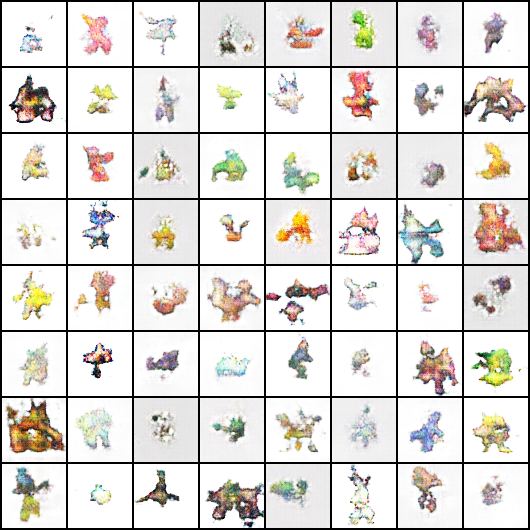

In [138]:
display(Image.open("samples/wgan_gp/epoch_200.png"))

VAE

In [116]:
class VAEEncoder(nn.Module):
    def __init__(self, z_dim=256):
        super().__init__()
        self.conv = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), nn.ReLU(),
        )
        self.fc_mu = nn.Linear(256 * 4 * 4, z_dim)
        self.fc_logvar = nn.Linear(256 * 4 * 4, z_dim)

    def forward(self, x):
        h = self.conv(x).flatten(1)
        return self.fc_mu(h), self.fc_logvar(h)


class VAEDecoder(nn.Module):
    def __init__(self, z_dim=256):
        super().__init__()
        self.fc = nn.Linear(z_dim, 256 * 4 * 4)
        self.deconv = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Tanh(),
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 256, 4, 4)
        return self.deconv(h)


class VAE(nn.Module):
    def __init__(self, z_dim=256):
        super().__init__()
        self.enc = VAEEncoder(z_dim)
        self.dec = VAEDecoder(z_dim)

    def reparameterize(self, mu, logvar):
        std = torch.exp(0.5 * logvar)
        eps = torch.randn_like(std)
        return mu + eps * std

    def forward(self, x):
        mu, logvar = self.enc(x)
        z = self.reparameterize(mu, logvar)
        x_hat = self.dec(z)
        return x_hat, mu, logvar


def vae_loss(x_hat, x, mu, logvar, beta=1.0):
    recon_l1 = nn.functional.l1_loss(x_hat, x, reduction="mean")
    recon_l2 = nn.functional.mse_loss(x_hat, x, reduction="mean")
    recon = 0.5 * recon_l1 + 0.5 * recon_l2
    kl = -0.5 * torch.mean(1 + logvar - mu.pow(2) - logvar.exp())
    total = recon + beta * kl
    return total, recon, kl


def train_vae(
    train_loader,
    test_loader,
    epochs=10,
    latent_dim=256,
    lr=2e-4,
    beta=1.0,
):
    os.makedirs("samples/vae", exist_ok=True)

    model = VAE(latent_dim).to(device)
    opt = optim.Adam(model.parameters(), lr=lr)

    fixed_z = torch.randn(64, latent_dim, device=device)

    history = {
        "train_loss": [],
        "train_recon": [],
        "train_kl": [],
        "test_loss": [],
        "test_recon": [],
        "test_kl": [],
    }

    for epoch in range(epochs):
        model.train()

        train_loss = 0.0
        train_recon = 0.0
        train_kl = 0.0
        train_batches = 0

        pbar = tqdm(train_loader, desc=f"VAE Epoch {epoch+1}/{epochs}")
        for real, _ in pbar:
            real = real.to(device)

            x_hat, mu, logvar = model(real)
            loss, recon, kl = vae_loss(x_hat, real, mu, logvar, beta=beta)

            opt.zero_grad()
            loss.backward()
            opt.step()

            train_loss += loss.item()
            train_recon += recon.item()
            train_kl += kl.item()
            train_batches += 1

            pbar.set_postfix(
                loss=float(loss.item()),
                recon=float(recon.item()),
                kl=float(kl.item()),
            )

        history["train_loss"].append(train_loss / train_batches)
        history["train_recon"].append(train_recon / train_batches)
        history["train_kl"].append(train_kl / train_batches)

        model.eval()
        test_loss = 0.0
        test_recon = 0.0
        test_kl = 0.0
        test_batches = 0

        with torch.no_grad():
            for real, _ in test_loader:
                real = real.to(device)

                x_hat, mu, logvar = model(real)
                loss, recon, kl = vae_loss(x_hat, real, mu, logvar, beta=beta)

                test_loss += loss.item()
                test_recon += recon.item()
                test_kl += kl.item()
                test_batches += 1

        history["test_loss"].append(test_loss / test_batches)
        history["test_recon"].append(test_recon / test_batches)
        history["test_kl"].append(test_kl / test_batches)

        with torch.no_grad():
            samples = model.dec(fixed_z)
            save_samples(samples, f"samples/vae/epoch_{epoch+1:03d}.png")

    torch.save(model.state_dict(), "vae.pt")
    torch.save(history, "vae_history.pt")

    return model, history

In [119]:
vae_model, hist_vae = train_vae(
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=200,
    latent_dim=512,
    lr=2e-4,
    beta=0.01,
)

VAE Epoch 200/200: 100%|██████████| 40/40 [00:01<00:00, 31.61it/s, kl=0.492, loss=0.0598, recon=0.0548]


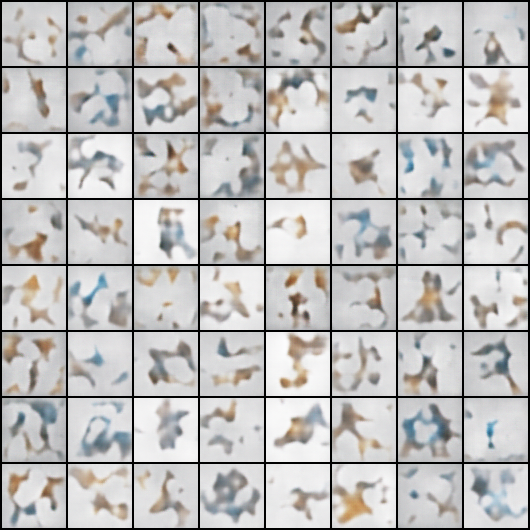

In [137]:
display(Image.open("samples/vae/epoch_200.png"))

WAE-MMD

In [143]:
class WAEEncoder(nn.Module):
    def __init__(self, z_dim=128):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 32, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(32, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), nn.ReLU(),
        )
        self.fc = nn.Linear(256 * 4 * 4, z_dim)

    def forward(self, x):
        return self.fc(self.net(x).flatten(1))


class WAEDecoder(nn.Module):
    def __init__(self, z_dim=128):
        super().__init__()
        self.fc = nn.Linear(z_dim, 256 * 4 * 4)
        self.net = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 32, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(32, 3, 4, 2, 1), nn.Tanh(),
        )

    def forward(self, z):
        h = self.fc(z).view(-1, 256, 4, 4)
        return self.net(h)


def imq_kernel(x, y, h_dim):
    x_norm = (x ** 2).sum(1, keepdim=True)
    y_norm = (y ** 2).sum(1, keepdim=True).t()
    dist = x_norm + y_norm - 2.0 * x @ y.t()
    C = 2 * h_dim * 1.0
    return C / (C + dist + 1e-8)


def mmd_loss(z, z_prior):
    k_xx = imq_kernel(z, z, z.size(1))
    k_yy = imq_kernel(z_prior, z_prior, z.size(1))
    k_xy = imq_kernel(z, z_prior, z.size(1))

    eye = torch.eye(z.size(0), device=z.device)
    k_xx = k_xx * (1 - eye)
    k_yy = k_yy * (1 - eye)

    mmd = k_xx.sum() / (z.size(0) * (z.size(0) - 1))
    mmd += k_yy.sum() / (z.size(0) * (z.size(0) - 1))
    mmd -= 2 * k_xy.mean()
    return mmd


def train_wae(
    train_loader,
    test_loader,
    epochs=10,
    latent_dim=128,
    lr=1e-4,
    lambda_mmd=10.0,
):
    os.makedirs("samples/wae_mmd", exist_ok=True)

    E = WAEEncoder(latent_dim).to(device)
    D = WAEDecoder(latent_dim).to(device)

    opt = optim.Adam(list(E.parameters()) + list(D.parameters()), lr=lr)
    fixed_z = torch.randn(64, latent_dim, device=device)

    history = {
        "train_loss": [],
        "train_recon": [],
        "train_mmd": [],
        "test_loss": [],
        "test_recon": [],
        "test_mmd": [],
    }

    for epoch in range(epochs):
        E.train()
        D.train()

        train_loss = 0.0
        train_recon = 0.0
        train_mmd = 0.0
        train_batches = 0

        pbar = tqdm(train_loader, desc=f"WAE Epoch {epoch+1}/{epochs}")
        for real, _ in pbar:
            real = real.to(device)

            z = E(real)
            recon = D(z)
            z_prior = torch.randn_like(z)

            recon_l1 = nn.functional.l1_loss(recon, real)
            recon_l2 = nn.functional.mse_loss(recon, real)
            recon_loss = 0.5 * recon_l1 + 0.5 * recon_l2
            mmd = mmd_loss(z, z_prior)
            loss = recon_loss + lambda_mmd * mmd

            opt.zero_grad()
            loss.backward()
            opt.step()

            train_loss += loss.item()
            train_recon += recon_loss.item()
            train_mmd += mmd.item()
            train_batches += 1

            pbar.set_postfix(
                loss=float(loss.item()),
                recon=float(recon_loss.item()),
                mmd=float(mmd.item()),
            )

        history["train_loss"].append(train_loss / train_batches)
        history["train_recon"].append(train_recon / train_batches)
        history["train_mmd"].append(train_mmd / train_batches)

        E.eval()
        D.eval()
        test_loss = 0.0
        test_recon = 0.0
        test_mmd = 0.0
        test_batches = 0

        with torch.no_grad():
            for real, _ in test_loader:
                real = real.to(device)

                z = E(real)
                recon = D(z)
                z_prior = torch.randn_like(z)

                recon_loss = nn.functional.l1_loss(recon, real)
                mmd = mmd_loss(z, z_prior)
                loss = recon_loss + lambda_mmd * mmd

                test_loss += loss.item()
                test_recon += recon_loss.item()
                test_mmd += mmd.item()
                test_batches += 1

        history["test_loss"].append(test_loss / test_batches)
        history["test_recon"].append(test_recon / test_batches)
        history["test_mmd"].append(test_mmd / test_batches)

        with torch.no_grad():
            samples = D(fixed_z)
            save_samples(samples, f"samples/wae_mmd/epoch_{epoch+1:03d}.png")

    torch.save({"encoder": E.state_dict(), "decoder": D.state_dict()}, "wae_mmd.pt")
    torch.save(history, "wae_mmd_history.pt")

    return E, D, history

In [144]:
wae_E, wae_D, hist_wae = train_wae(
    train_loader=train_loader,
    test_loader=test_loader,
    epochs=200,
    latent_dim=512,
    lr=1e-4,
    lambda_mmd=10.0,
)

WAE Epoch 200/200: 100%|██████████| 40/40 [00:01<00:00, 30.95it/s, loss=0.255, mmd=0.0184, recon=0.0718]    


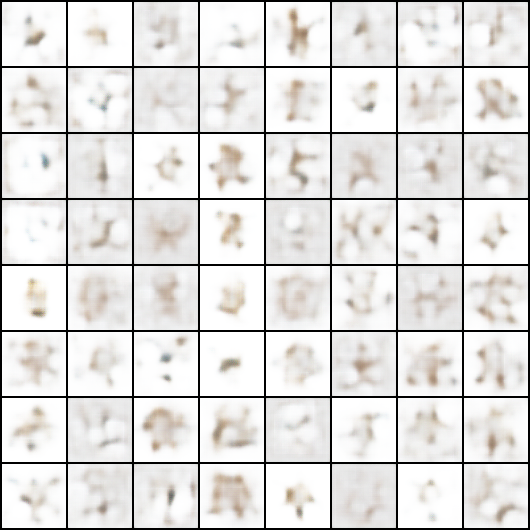

In [145]:
display(Image.open("samples/wae_mmd/epoch_200.png"))

WINN

In [140]:
import torch.nn.functional as F

def smooth_noise(batch_size, img_size=64, downsample=8):
    small = torch.randn(batch_size, 3, downsample, downsample, device=device)
    x = F.interpolate(small, size=(img_size, img_size), mode="bilinear", align_corners=False)
    return x.clamp(-1, 1)

def total_variation(x):
    tv_h = (x[:, :, 1:, :] - x[:, :, :-1, :]).abs().mean()
    tv_w = (x[:, :, :, 1:] - x[:, :, :, :-1]).abs().mean()
    return tv_h + tv_w

def synthesize_negatives(
    model,
    batch_size,
    img_size=64,
    steps=40,
    step_lr=0.01,
    noise_std=0.0,
    tv_weight=0.01,
):
    x = smooth_noise(batch_size, img_size=img_size, downsample=8)
    x = x.detach().requires_grad_(True)

    for _ in range(steps):
        logits = model(x)
        loss = -logits.mean() + tv_weight * total_variation(x)

        grad = torch.autograd.grad(loss, x, create_graph=False)[0]
        grad = grad / (grad.abs().mean(dim=(1, 2, 3), keepdim=True) + 1e-8)

        x = x - step_lr * grad

        if noise_std > 0:
            x = x + noise_std * torch.randn_like(x)

        x = x.clamp(-1, 1)
        x = x.detach().requires_grad_(True)

    return x.detach()

In [141]:
winn_model, hist_winn = train_winn(
    train_loader=train_loader,
    epochs=10,
    lr=1e-4,
    synth_steps=40,
    synth_lr=0.01,
    noise_std=0.0,
    image_size=64,
)

WINN Epoch 10/10: 100%|██████████| 40/40 [00:16<00:00,  2.45it/s, fake_logit=-20.7, loss=0, real_logit=21.6]      


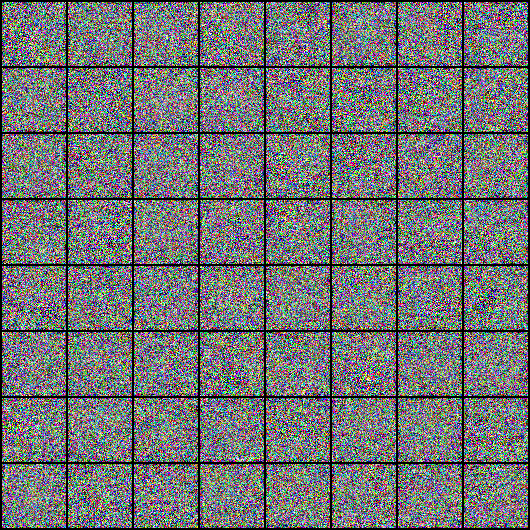

In [135]:
display(Image.open("samples/winn/epoch_100.png"))

Stable Diffusion

In [146]:
LATENT_CH = 4
T = 1000


class LDMEncoder(nn.Module):
    def __init__(self, latent_ch=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.Conv2d(3, 64, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(64, 128, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(128, 256, 4, 2, 1), nn.ReLU(),
            nn.Conv2d(256, latent_ch, 4, 2, 1),
        )

    def forward(self, x):
        return self.net(x)


class LDMDecoder(nn.Module):
    def __init__(self, latent_ch=4):
        super().__init__()
        self.net = nn.Sequential(
            nn.ConvTranspose2d(latent_ch, 256, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(256, 128, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(128, 64, 4, 2, 1), nn.ReLU(),
            nn.ConvTranspose2d(64, 3, 4, 2, 1), nn.Tanh(),
        )

    def forward(self, z):
        return self.net(z)


class TinyAE(nn.Module):
    def __init__(self, latent_ch=4):
        super().__init__()
        self.encoder = LDMEncoder(latent_ch)
        self.decoder = LDMDecoder(latent_ch)

    def encode(self, x):
        return self.encoder(x)

    def decode(self, z):
        return self.decoder(z)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)


def sinusoidal_embedding(timesteps, dim):
    half = dim // 2
    emb = math.log(10000) / (half - 1)
    emb = torch.exp(torch.arange(half, device=timesteps.device) * -emb)
    emb = timesteps[:, None] * emb[None, :]
    emb = torch.cat([torch.sin(emb), torch.cos(emb)], dim=1)
    return emb


class ResBlock(nn.Module):
    def __init__(self, ch, tdim):
        super().__init__()
        self.conv1 = nn.Conv2d(ch, ch, 3, 1, 1)
        self.conv2 = nn.Conv2d(ch, ch, 3, 1, 1)
        self.tproj = nn.Linear(tdim, ch)
        self.act = nn.SiLU()

    def forward(self, x, t_emb):
        h = self.act(self.conv1(x))
        h = h + self.tproj(t_emb)[:, :, None, None]
        h = self.act(self.conv2(h))
        return x + h


class TinyUNet(nn.Module):
    def __init__(self, in_ch=4, base=64, tdim=128):
        super().__init__()
        self.time_mlp = nn.Sequential(
            nn.Linear(tdim, tdim),
            nn.SiLU(),
            nn.Linear(tdim, tdim)
        )

        self.in_conv = nn.Conv2d(in_ch, base, 3, 1, 1)
        self.rb1 = ResBlock(base, tdim)
        self.down = nn.Conv2d(base, base * 2, 4, 2, 1)
        self.rb2 = ResBlock(base * 2, tdim)
        self.mid = ResBlock(base * 2, tdim)
        self.up = nn.ConvTranspose2d(base * 2, base, 4, 2, 1)
        self.rb3 = ResBlock(base, tdim)
        self.out = nn.Conv2d(base, in_ch, 3, 1, 1)
        self.tdim = tdim

    def forward(self, x, t):
        t_emb = sinusoidal_embedding(t, self.tdim)
        t_emb = self.time_mlp(t_emb)

        x1 = self.in_conv(x)
        x1 = self.rb1(x1, t_emb)
        x2 = self.down(x1)
        x2 = self.rb2(x2, t_emb)
        x2 = self.mid(x2, t_emb)
        x3 = self.up(x2)
        x3 = x3 + x1
        x3 = self.rb3(x3, t_emb)
        return self.out(x3)

In [147]:
def make_diffusion_schedule(T, device):
    betas = torch.linspace(1e-4, 0.02, T, device=device)
    alphas = 1.0 - betas
    alphas_cumprod = torch.cumprod(alphas, dim=0)
    sqrt_alphas_cumprod = torch.sqrt(alphas_cumprod)
    sqrt_one_minus_alphas_cumprod = torch.sqrt(1 - alphas_cumprod)
    return betas, alphas, alphas_cumprod, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod


betas, alphas, alphas_cumprod, sqrt_alphas_cumprod, sqrt_one_minus_alphas_cumprod = make_diffusion_schedule(T, device)


def q_sample(x0, t, noise):
    return (
        sqrt_alphas_cumprod[t][:, None, None, None] * x0 +
        sqrt_one_minus_alphas_cumprod[t][:, None, None, None] * noise
    )


@torch.no_grad()
def sample_latents(model, n=64, shape=(4, 4, 4)):
    model.eval()
    x = torch.randn(n, *shape, device=device)

    for time_idx in reversed(range(T)):
        t = torch.full((n,), time_idx, device=device, dtype=torch.long)
        eps_theta = model(x, t)

        a = alphas[time_idx]
        ac = alphas_cumprod[time_idx]
        b = betas[time_idx]

        if time_idx > 0:
            z = torch.randn_like(x)
        else:
            z = torch.zeros_like(x)

        x = (1 / torch.sqrt(a)) * (
            x - ((1 - a) / torch.sqrt(1 - ac)) * eps_theta
        ) + torch.sqrt(b) * z

    return x

In [148]:
def train_latent_diffusion(
    train_loader,
    epochs_ae=5,
    epochs_diff=5,
    latent_ch=4,
    lr=2e-4,
):
    os.makedirs("samples/latent_diffusion", exist_ok=True)

    ae = TinyAE(latent_ch).to(device)
    opt_ae = optim.Adam(ae.parameters(), lr=lr)

    ae_history = {"loss": []}

    for epoch in range(epochs_ae):
        ae.train()
        epoch_loss = 0.0
        num_batches = 0

        pbar = tqdm(train_loader, desc=f"AE Epoch {epoch+1}/{epochs_ae}")
        for real, _ in pbar:
            real = real.to(device)
            recon = ae(real)
            loss = nn.functional.l1_loss(recon, real)

            opt_ae.zero_grad()
            loss.backward()
            opt_ae.step()

            epoch_loss += loss.item()
            num_batches += 1

            pbar.set_postfix(loss=float(loss.item()))

        ae_history["loss"].append(epoch_loss / num_batches)

    unet = TinyUNet(in_ch=latent_ch).to(device)
    opt_diff = optim.Adam(unet.parameters(), lr=lr)

    diff_history = {"loss": []}

    for epoch in range(epochs_diff):
        unet.train()
        epoch_loss = 0.0
        num_batches = 0

        pbar = tqdm(train_loader, desc=f"Diffusion Epoch {epoch+1}/{epochs_diff}")
        for real, _ in pbar:
            real = real.to(device)

            with torch.no_grad():
                z0 = ae.encode(real)

            t = torch.randint(0, T, (z0.size(0),), device=device)
            noise = torch.randn_like(z0)
            zt = q_sample(z0, t, noise)
            pred = unet(zt, t)

            loss = nn.functional.mse_loss(pred, noise)

            opt_diff.zero_grad()
            loss.backward()
            opt_diff.step()

            epoch_loss += loss.item()
            num_batches += 1

            pbar.set_postfix(loss=float(loss.item()))

        diff_history["loss"].append(epoch_loss / num_batches)

        with torch.no_grad():
            z = sample_latents(unet, n=64, shape=(latent_ch, 4, 4))
            imgs = ae.decode(z)
            save_samples(imgs, f"samples/latent_diffusion/epoch_{epoch+1:03d}.png")

    history = {
        "ae_loss": ae_history["loss"],
        "diff_loss": diff_history["loss"],
    }

    torch.save({"ae": ae.state_dict(), "unet": unet.state_dict()}, "latent_diffusion.pt")
    torch.save(history, "latent_diffusion_history.pt")

    return ae, unet, history

In [149]:
ae_ldm, unet_ldm, hist_ldm = train_latent_diffusion(
    train_loader=train_loader,
    epochs_ae=50,
    epochs_diff=100,
    latent_ch=8,
    lr=2e-4,
)

Diffusion Epoch 100/100: 100%|██████████| 40/40 [00:01<00:00, 37.40it/s, loss=0.317]


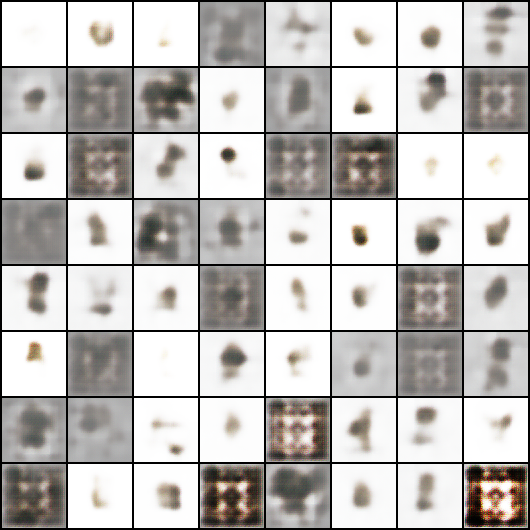

In [151]:
display(Image.open("samples/latent_diffusion/epoch_100.png"))

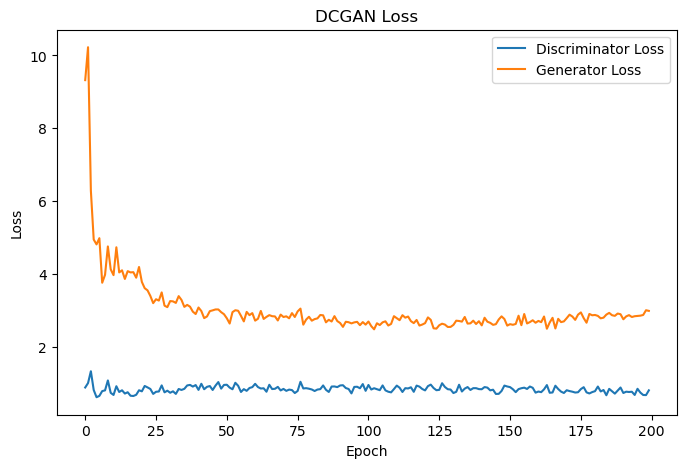

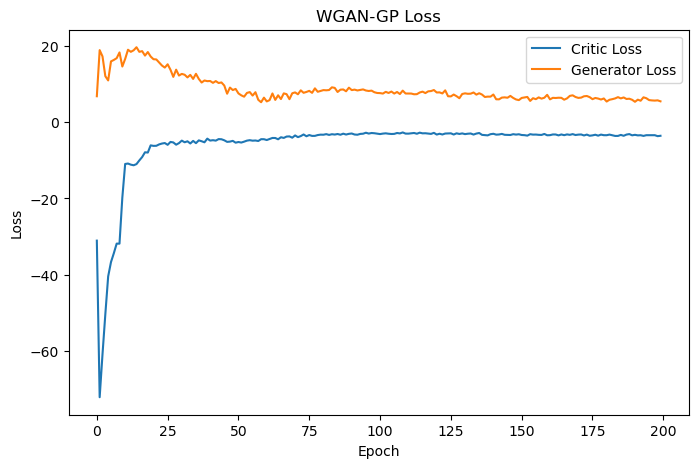

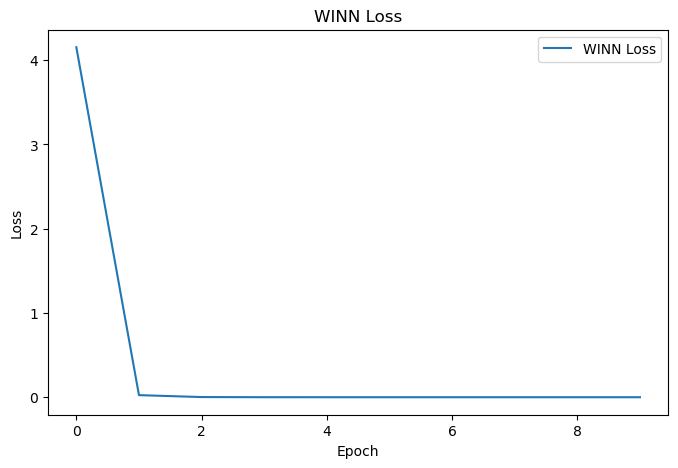

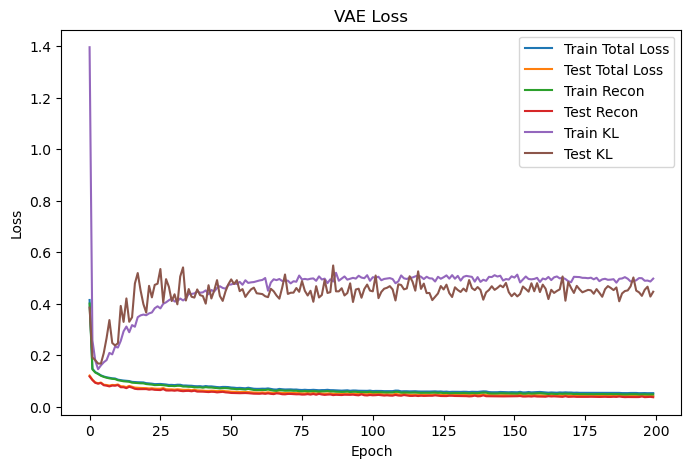

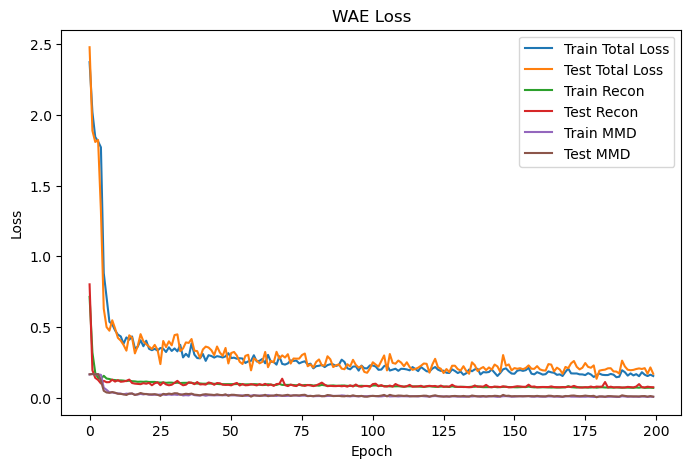

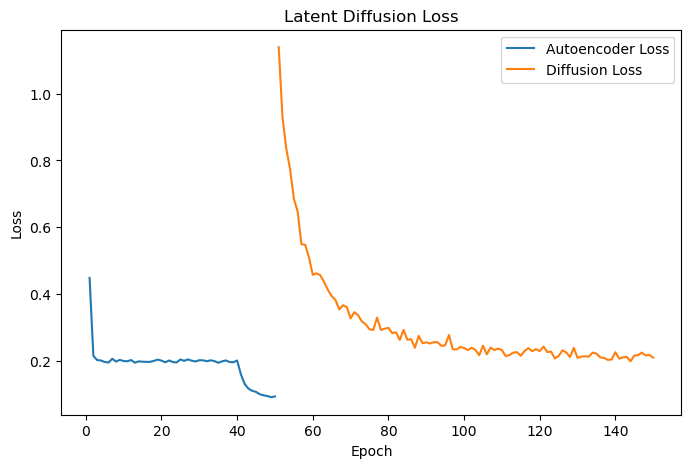

In [193]:
# ---------- DCGAN ----------
plt.figure(figsize=(8, 5))
plt.plot(hist_dcgan["lossD"], label="Discriminator Loss")
plt.plot(hist_dcgan["lossG"], label="Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("DCGAN Loss")
plt.legend()
plt.show()

# ---------- WGAN-GP ----------
plt.figure(figsize=(8, 5))
plt.plot(hist_wgan["lossC"], label="Critic Loss")
plt.plot(hist_wgan["lossG"], label="Generator Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("WGAN-GP Loss")
plt.legend()
plt.show()

# ---------- WINN ----------
plt.figure(figsize=(8, 5))
plt.plot(hist_winn["loss"], label="WINN Loss")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("WINN Loss")
plt.legend()
plt.show()

# ---------- VAE ----------
plt.figure(figsize=(8, 5))
plt.plot(hist_vae["train_loss"], label="Train Total Loss")
plt.plot(hist_vae["test_loss"], label="Test Total Loss")
plt.plot(hist_vae["train_recon"], label="Train Recon")
plt.plot(hist_vae["test_recon"], label="Test Recon")
plt.plot(hist_vae["train_kl"], label="Train KL")
plt.plot(hist_vae["test_kl"], label="Test KL")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("VAE Loss")
plt.legend()
plt.show()

# ---------- WAE ----------
plt.figure(figsize=(8, 5))
plt.plot(hist_wae["train_loss"], label="Train Total Loss")
plt.plot(hist_wae["test_loss"], label="Test Total Loss")
plt.plot(hist_wae["train_recon"], label="Train Recon")
plt.plot(hist_wae["test_recon"], label="Test Recon")
plt.plot(hist_wae["train_mmd"], label="Train MMD")
plt.plot(hist_wae["test_mmd"], label="Test MMD")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("WAE Loss")
plt.legend()
plt.show()

# ---------- Diffusion ----------
plt.figure(figsize=(8, 5))
plt.plot(range(1, len(hist_ldm["ae_loss"]) + 1), hist_ldm["ae_loss"], label="Autoencoder Loss")
plt.plot(
    range(len(hist_ldm["ae_loss"]) + 1, len(hist_ldm["ae_loss"]) + len(hist_ldm["diff_loss"]) + 1),
    hist_ldm["diff_loss"],
    label="Diffusion Loss"
)
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.title("Latent Diffusion Loss")
plt.legend()
plt.show()

evaluation

In [152]:
!pip install torch-fidelity

In [153]:
import os
from torchvision.utils import save_image

def save_real_images_from_loader(loader, out_dir, max_images=500):
    os.makedirs(out_dir, exist_ok=True)
    count = 0

    for imgs, _ in loader:
        for img in imgs:
            if count >= max_images:
                return
            save_image((img + 1) / 2, os.path.join(out_dir, f"{count:05d}.png"))
            count += 1

In [154]:
save_real_images_from_loader(test_loader, "eval/real_pokemon", max_images=160)

In [156]:
def save_dcgan_images(G, out_dir, n=160, latent_dim=64):
    os.makedirs(out_dir, exist_ok=True)
    G.eval()

    with torch.no_grad():
        for i in range(n):
            z = torch.randn(1, latent_dim, 1, 1, device=device)
            img = G(z)
            save_image((img + 1) / 2, os.path.join(out_dir, f"{i:05d}.png"))

In [157]:
save_dcgan_images(G_dcgan, "eval/dcgan", n=160, latent_dim=64)

In [158]:
def save_wgan_images(G, out_dir, n=160, latent_dim=64):
    os.makedirs(out_dir, exist_ok=True)
    G.eval()

    with torch.no_grad():
        for i in range(n):
            z = torch.randn(1, latent_dim, 1, 1, device=device)
            img = G(z)
            save_image((img + 1) / 2, os.path.join(out_dir, f"{i:05d}.png"))

In [159]:
save_wgan_images(G_wgan, "eval/wgan_gp", n=160, latent_dim=64)

In [160]:
def save_vae_images(model, out_dir, n=160, latent_dim=512):
    os.makedirs(out_dir, exist_ok=True)
    model.eval()

    with torch.no_grad():
        for i in range(n):
            z = torch.randn(1, latent_dim, device=device)
            img = model.dec(z)
            save_image((img + 1) / 2, os.path.join(out_dir, f"{i:05d}.png"))

In [161]:
save_vae_images(vae_model, "eval/vae", n=160, latent_dim=512)

In [162]:
def save_wae_images(decoder, out_dir, n=160, latent_dim=512):
    os.makedirs(out_dir, exist_ok=True)
    decoder.eval()

    with torch.no_grad():
        for i in range(n):
            z = torch.randn(1, latent_dim, device=device)
            img = decoder(z)
            save_image((img + 1) / 2, os.path.join(out_dir, f"{i:05d}.png"))

In [163]:
save_wae_images(wae_D, "eval/wae", n=160, latent_dim=512)

In [178]:
def save_winn_images(model, out_dir, n=160, batch_size=16, image_size=64,
                     synth_steps=30, synth_lr=0.01, noise_std=0.003):
    os.makedirs(out_dir, exist_ok=True)
    model.eval()

    count = 0
    while count < n:
        current_batch = min(batch_size, n - count)

        fake = synthesize_negatives(
            model,
            batch_size=current_batch,
            img_size=image_size,
            steps=synth_steps,
            step_lr=synth_lr,
            noise_std=noise_std,
        )

        for img in fake:
            save_image((img + 1) / 2, os.path.join(out_dir, f"{count:05d}.png"))
            count += 1

In [179]:
save_winn_images(
    winn_model,
    "eval/winn",
    n=160,
    batch_size=16,
    image_size=64,
    synth_steps=30,
    synth_lr=0.01,
    noise_std=0.003,
)

In [175]:
def save_diffusion_images(ae, unet, out_dir, n=160, batch_size=16, latent_ch=4):
    os.makedirs(out_dir, exist_ok=True)
    ae.eval()
    unet.eval()

    count = 0
    while count < n:
        current_batch = min(batch_size, n - count)

        with torch.no_grad():
            z = sample_latents(unet, n=current_batch, shape=(latent_ch, 4, 4))
            imgs = ae.decode(z)

        for img in imgs:
            save_image((img + 1) / 2, os.path.join(out_dir, f"{count:05d}.png"))
            count += 1

In [177]:
save_diffusion_images(
    ae_ldm,
    unet_ldm,
    "eval/diffusion",
    n=160,
    batch_size=16,
    latent_ch=8,
)

In [166]:
from torch_fidelity import calculate_metrics

In [168]:
metrics_dcgan = calculate_metrics(
    input1="eval/real_pokemon",
    input2="eval/dcgan",
    cuda=False,
    fid=True,
    isc=False,
    kid=False,
    verbose=False,
)

metrics_dcgan

{'frechet_inception_distance': 206.73089152774105}

In [169]:
metrics_dcgan["frechet_inception_distance"]

206.73089152774105

In [187]:
metrics_wgan = calculate_metrics(
    input1="eval/real_pokemon",
    input2="eval/wgan_gp",
    cuda=False,
    fid=True,
    isc=False,
    kid=False,
    verbose=False,
)

metrics_wgan

{'frechet_inception_distance': 228.17612612488685}

In [188]:
metrics_wgan["frechet_inception_distance"]

228.17612612488685

In [172]:
metrics_vae = calculate_metrics(
    input1="eval/real_pokemon",
    input2="eval/vae",
    cuda=False,
    fid=True,
    isc=False,
    kid=False,
    verbose=False,
)

metrics_vae["frechet_inception_distance"]

411.13567220083576

In [173]:
metrics_wae = calculate_metrics(
    input1="eval/real_pokemon",
    input2="eval/wae",
    cuda=False,
    fid=True,
    isc=False,
    kid=False,
    verbose=False,
)

metrics_wae["frechet_inception_distance"]

364.5445948119826

In [180]:
metrics_winn = calculate_metrics(
    input1="eval/real_pokemon",
    input2="eval/winn",
    cuda=False,
    fid=True,
    isc=False,
    kid=False,
    verbose=False,
)

metrics_winn["frechet_inception_distance"]

446.60086286563444

In [181]:
metrics_diffusion = calculate_metrics(
    input1="eval/real_pokemon",
    input2="eval/diffusion",
    cuda=False,
    fid=True,
    isc=False,
    kid=False,
    verbose=False,
)

metrics_diffusion["frechet_inception_distance"]

354.54973272773344

In [183]:
metrics_diffusion

{'frechet_inception_distance': 354.54973272773344}

In [189]:
import pandas as pd

results = pd.DataFrame([
    {"Model": "DCGAN", "FID": metrics_dcgan["frechet_inception_distance"]},
    {"Model": "WGAN-GP", "FID": metrics_wgan["frechet_inception_distance"]},
    {"Model": "WINN", "FID": metrics_winn["frechet_inception_distance"]},
    {"Model": "VAE", "FID": metrics_vae["frechet_inception_distance"]},
    {"Model": "WAE", "FID": metrics_wae["frechet_inception_distance"]},
    {"Model": "Diffusion", "FID": metrics_diffusion["frechet_inception_distance"]},
])

results.sort_values("FID")

,Model,FID
0,DCGAN,206.730892
1,WGAN-GP,228.176126
5,Diffusion,354.549733
4,WAE,364.544595
3,VAE,411.135672
2,WINN,446.600863
